Robust MPC: Simulation with linearized rocket system

In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [101]:
from LandMPC.MPCControl_z import MPCControl_z
from src.rocket import Rocket
from src.pos_rocket_vis import *

# Require ipympl
%matplotlib widget 

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

sim_time = 4.0  # simulation length in seconds
x0 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10])
x_ref = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3])
xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)
sys = rocket.linearize_sys(xs, us)
A, B = sys.A, sys.B

H = 3.0
mpc = MPCControl_z(A, B, xs, us, Ts, H)

Linearization around a steady state:
x_ref =  [0 0 0 0 0 0 0 0 0 0 0 3]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]


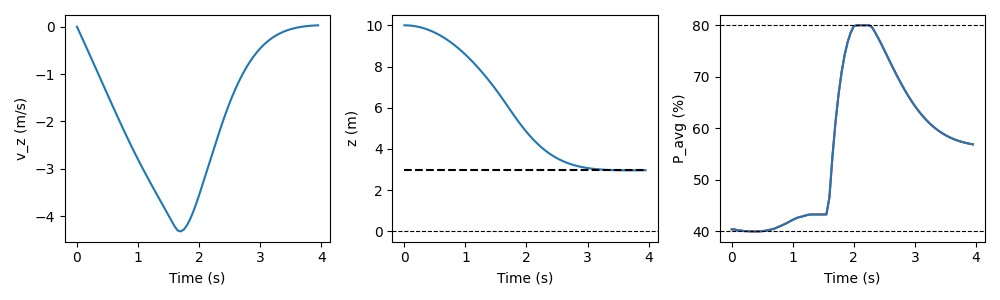

In [103]:
t_cl, x_cl, u_cl = rocket.simulate_subsystem(mpc, sim_time, x0, w_type='no_noise')
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs, 'sys_z')

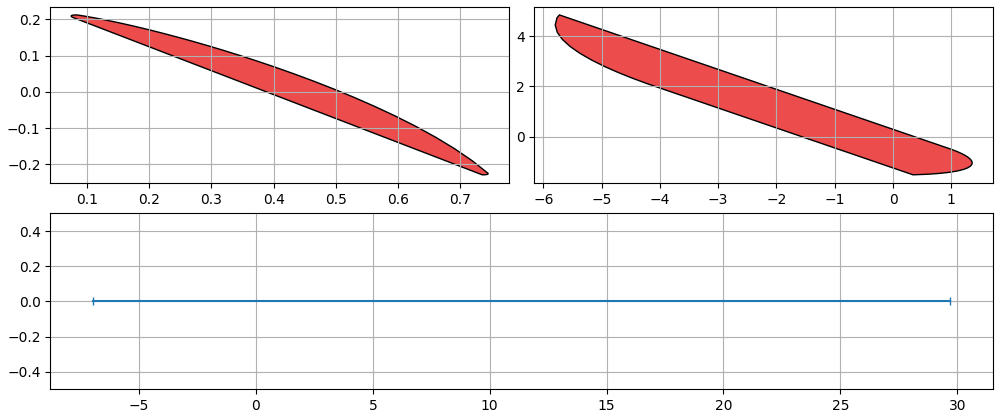

In [28]:
assert not mpc.E.is_empty
assert not mpc.X_tilde.is_empty
assert not mpc.U_tilde.is_empty
assert not mpc.Xf_tilde.is_empty

OPACITY = 0.7
COLOR = 'xkcd:red'

plt.close('all')
plt.figure('Terminal invariant set', (10, 4.2))

ax = plt.subplot(221)
mpc.E.plot(ax, color=COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.grid()

ax = plt.subplot(222)
mpc.Xf_tilde.plot(ax, color=COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.grid()

ax = plt.subplot(212)
ax.plot(mpc.U_tilde.V[:, 0], np.zeros_like(mpc.U_tilde.V)[:, 0], marker='|')
ax.set_ylim(-0.5, 0.5)
ax.grid()

plt.tight_layout(pad=0.5)
plt.show()

In [29]:
t_cl, x_cl, u_cl = rocket.simulate_subsystem(mpc, sim_time, x0, w_type='random')

In [ ]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl)

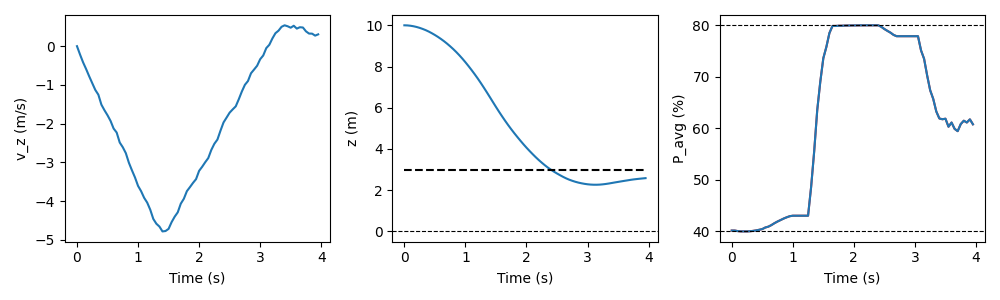

In [30]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs, 'sys_z')

In [31]:
t_cl, x_cl, u_cl = rocket.simulate_subsystem(mpc, sim_time, x0, w_type='extreme')

c:\Users\killi\Desktop\MPC-Course-EPFL\.env\Lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


AssertionError: 

In [ ]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl)

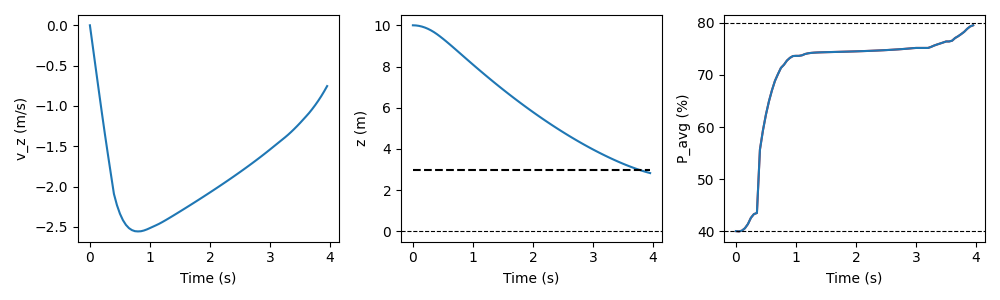

In [17]:

plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs, 'sys_z')